# 03 · Bluff position, DSAS metrics and GIE correction

For one cluster:

1. **Bias filter**: each (beam, date) profile is compared at `X0` with the reference beam; profiles within the bias tolerance are kept.
2. **Bluff**: the reference elevation is the mid-height of the oldest profile; the bluff position `bluff_x` is where each profile first crosses it.
3. **DSAS metrics** on `bluff_x` over time: NSM (first − last), SCE, EPR, LRR (x increases landward, so retreat is negative).
4. **GIE correction**: beams cross the coast at an angle and are offset from the reference beam by `d_signed`, so part of the measured change is geometric:

   `NSM_geo = coast_slope_sign · d_signed · tan(90° − angle)`  and  `bluff_x_gie = bluff_x + NSM_geo`.

Requires the package installed from the repository root (`pip install -e .`).
Paths come from `configs/north_slope.toml`; all parameters and their defaults are in `src/is2retreat/config.py`.

In [1]:
TRACK_ID = "0129"
CONFIG = "../configs/north_slope.toml"
SOURCE = "auto"
BIAS_TOLERANCE = 0.5   # m
GT_FAMILY = None       # e.g. "gt2"; None = family of the cluster with most beams
CLUSTER_ID = None      # None = cluster with most beams

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from is2retreat import load_config, prepare_track_inputs
from is2retreat.bluff import process_cluster_with_reference
from is2retreat.gie import (
    apply_dynamic_gie_to_cluster_bluff_df,
    compute_cluster_statistics_from_x,
    run_gie_dynamic_for_bias_values,
)
from is2retreat.metrics import compute_cluster_statistics
from is2retreat.workflow import run_workflow

paths, params = load_config(CONFIG)
inputs = prepare_track_inputs(TRACK_ID, paths, params, source=SOURCE, verbose=False)

## Clusters and bias filter for this tolerance

In [3]:
wf = run_workflow(inputs.track_id, inputs.dataset_raw, inputs.shoreline_gdf,
                  bias_tolerance=BIAS_TOLERANCE, params=params, utm_epsg=inputs.utm_epsg)
selected = wf.selected_clusters

if CLUSTER_ID is None:
    pick = selected.sort_values(["num_beams", "cluster_id"], ascending=[False, True]).iloc[0]
    GT_FAMILY, CLUSTER_ID = pick["gt_family"], int(pick["cluster_id"])

cluster_rows = selected[(selected["gt_family"] == GT_FAMILY) & (selected["cluster_id"] == CLUSTER_ID)]
print(f"Cluster {GT_FAMILY}-{CLUSTER_ID}: {int(cluster_rows['num_beams'].iloc[0])} beams, "
      f"width {cluster_rows['cluster_width_m'].iloc[0]:.0f} m, median angle {cluster_rows['angle_median_deg'].iloc[0]} deg")

bias_col = f"bias_{int(round(params.X0))}"
wf.bias_df[(wf.bias_df["gt_family"] == GT_FAMILY) & (wf.bias_df["cluster_id"] == CLUSTER_ID)][
    ["beam_id", "acq_date", bias_col, "keep", "is_ref"]]

Cluster gt1-4: 13 beams, width 134 m, median angle 87.1 deg


,beam_id,acq_date,bias_500,keep,is_ref
19,sliderule_0129_gt1l_cyc18_20221229,2022-12-29,0.000000,True,True
20,sliderule_0129_gt1l_cyc03_20190406,2019-04-06,0.167816,True,False
21,sliderule_0129_gt1l_cyc06_20200104,2020-01-04,0.041168,True,False
22,sliderule_0129_gt1l_cyc08_20200703,2020-07-03,-0.181632,True,False
23,sliderule_0129_gt1l_cyc11_20210402,2021-04-02,0.099200,True,False
24,sliderule_0129_gt1l_cyc14_20211230,2021-12-30,0.056467,True,False
25,sliderule_0129_gt1l_cyc19_20230329,2023-03-29,0.065221,True,False
26,sliderule_0129_gt1l_cyc23_20240327,2024-03-27,0.189546,True,False
27,sliderule_0129_gt1l_cyc26_20241224,2024-12-24,0.026653,True,False
28,sliderule_0129_gt1r_cyc07_20200403,2020-04-03,0.278610,True,False


## Bluff position per profile

In [4]:
bluff_df, y_ref = process_cluster_with_reference(
    wf.filtered_profiles, selected, cluster_id=CLUSTER_ID, gt_family=GT_FAMILY,
    which=params.BLUFF_WHICH, gap_threshold=params.GAP_THRESHOLD_M,
    atol=params.CROSSING_ATOL, bias_df=wf.bias_df,
)
print(f"Reference elevation: {y_ref:.2f} m")
bluff_df.sort_values("acq_date")

Reference elevation: 0.68 m


,beam_id,acq_date,bluff_x,bluff_y,ref_line
0,sliderule_0129_gt1l_cyc03_20190406,2019-04-06,250.927789,0.676,0.676
1,sliderule_0129_gt1l_cyc06_20200104,2020-01-04,286.949511,0.676,0.676
9,sliderule_0129_gt1r_cyc07_20200403,2020-04-03,266.094250,0.676,0.676
2,sliderule_0129_gt1l_cyc08_20200703,2020-07-03,291.217133,0.676,0.676
3,sliderule_0129_gt1l_cyc11_20210402,2021-04-02,286.011879,0.676,0.676
10,sliderule_0129_gt1r_cyc12_20210702,2021-07-02,331.041776,0.676,0.676
4,sliderule_0129_gt1l_cyc14_20211230,2021-12-30,308.954829,0.676,0.676
5,sliderule_0129_gt1l_cyc18_20221229,2022-12-29,326.465454,0.676,0.676
6,sliderule_0129_gt1l_cyc19_20230329,2023-03-29,315.181970,0.676,0.676
11,sliderule_0129_gt1r_cyc22_20231227,2023-12-27,333.519960,0.676,0.676


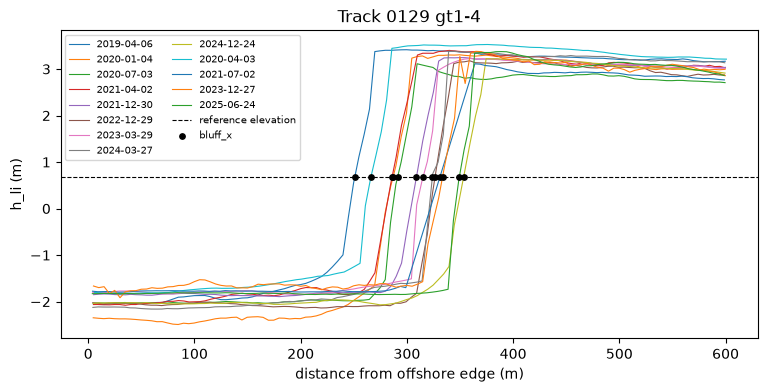

In [11]:
prof = wf.filtered_profiles[(wf.filtered_profiles["gt_family"] == GT_FAMILY)
                            & (wf.filtered_profiles["cluster_id"] == CLUSTER_ID)]
fig, ax = plt.subplots(figsize=(9, 4))
for (bid, dt), g in prof.groupby(["beam_id", "acq_date"]):
    g = g.sort_values("distance_from_offshore")
    ax.plot(g["distance_from_offshore"], g["h_li"], linewidth=0.8, label=pd.Timestamp(dt).date())
ax.axhline(y_ref, color="k", linestyle="--", linewidth=0.8, label="reference elevation")
ax.scatter(bluff_df["bluff_x"], bluff_df["bluff_y"], color="k", zorder=5, s=15, label="bluff_x")
ax.set_xlabel("distance from offshore edge (m)")
ax.set_ylabel("h_li (m)")
ax.set_title(f"Track {inputs.track_id} {GT_FAMILY}-{CLUSTER_ID}")
ax.legend(fontsize=7, ncol=2)
plt.show()

## DSAS metrics (measured)

In [6]:
measured = compute_cluster_statistics(
    bluff_df, confidence=params.CONFIDENCE, min_span_days=params.MIN_SPAN_DAYS,
    positional_uncertainty_m=params.POSITIONAL_UNCERTAINTY_M,
)
pd.Series(measured)

NSM                           -98
SCE                           102
EPR                        -15.83
LRR                        -14.06
LR2                          0.82
LSE                         13.84
LCI                          4.35
TemporalSpan_days            2271
ValidRegression              True
ClusterTemporalSpanYears     6.22
U_position_m                  4.8
U_NSM_m                      6.79
U_EPR_myr                    1.09
dtype: object

## GIE correction

In [7]:
coastline = inputs.shoreline_gdf.to_crs(selected.crs)
gie_df = apply_dynamic_gie_to_cluster_bluff_df(
    bluff_df=bluff_df,
    cluster_rows=cluster_rows,
    filtered_profiles=wf.filtered_profiles,
    coastline_gdf=coastline,
    beam_angle_table=wf.beam_angle_table,
    fallback_angle_col=params.GIE_FALLBACK_ANGLE_COL,
)
gie_df[["beam_id", "acq_date", "bluff_x", "d_signed", "angle_used_deg", "angle_source",
        "coast_slope_sign", "NSM_geo", "bluff_x_gie"]].sort_values("acq_date")

,beam_id,acq_date,bluff_x,d_signed,angle_used_deg,angle_source,coast_slope_sign,NSM_geo,bluff_x_gie
0,sliderule_0129_gt1l_cyc03_20190406,2019-04-06,250.927789,0.000000,87.36,per_beam,1,0.000000,250.927789
1,sliderule_0129_gt1l_cyc06_20200104,2020-01-04,286.949511,29.034922,87.30,per_beam,1,1.369252,288.318763
2,sliderule_0129_gt1r_cyc07_20200403,2020-04-03,266.094250,116.541558,78.70,per_beam,1,23.287301,289.381551
3,sliderule_0129_gt1l_cyc08_20200703,2020-07-03,291.217133,-1.645266,87.10,per_beam,1,-0.083346,291.133787
4,sliderule_0129_gt1l_cyc11_20210402,2021-04-02,286.011879,53.833658,82.48,per_beam,1,7.106454,293.118333
5,sliderule_0129_gt1r_cyc12_20210702,2021-07-02,331.041776,77.811422,78.97,per_beam,1,15.167294,346.209069
6,sliderule_0129_gt1l_cyc14_20211230,2021-12-30,308.954829,-7.299605,87.32,per_beam,1,-0.341687,308.613142
7,sliderule_0129_gt1l_cyc18_20221229,2022-12-29,326.465454,-17.823332,87.33,per_beam,1,-0.831174,325.634280
8,sliderule_0129_gt1l_cyc19_20230329,2023-03-29,315.181970,-5.463677,87.27,per_beam,1,-0.260528,314.921442
9,sliderule_0129_gt1r_cyc22_20231227,2023-12-27,333.519960,88.746617,79.00,per_beam,1,17.250595,350.770555


In [8]:
stats_kwargs = dict(confidence=params.CONFIDENCE, min_span_days=params.MIN_SPAN_DAYS,
                    positional_uncertainty_m=params.POSITIONAL_UNCERTAINTY_M)
comparison = pd.DataFrame({
    "measured": compute_cluster_statistics_from_x(gie_df, x_col="bluff_x", **stats_kwargs),
    "GIE corrected": compute_cluster_statistics_from_x(gie_df, x_col="bluff_x_gie", **stats_kwargs),
}).loc[["NSM", "SCE", "EPR", "LRR", "LR2", "TemporalSpan_days"]]
comparison

,measured,GIE corrected
NSM,-98,-116
SCE,102,116
EPR,-15.83,-18.68
LRR,-14.06,-15.02
LR2,0.82,0.81
TemporalSpan_days,2271,2271


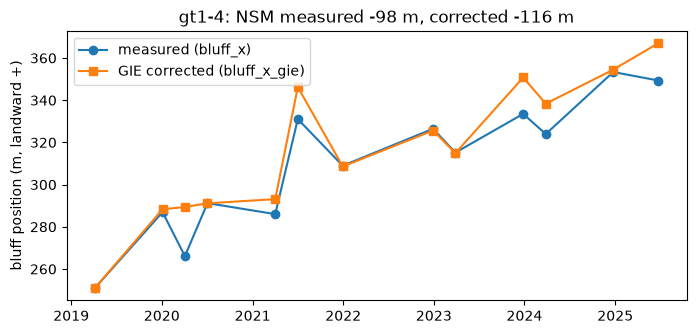

In [9]:
g = gie_df.sort_values("acq_date")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(g["acq_date"], g["bluff_x"], "o-", label="measured (bluff_x)")
ax.plot(g["acq_date"], g["bluff_x_gie"], "s-", label="GIE corrected (bluff_x_gie)")
ax.set_ylabel("bluff position (m, landward +)")
ax.set_title(f"{GT_FAMILY}-{CLUSTER_ID}: NSM measured {comparison.loc['NSM', 'measured']} m, "
             f"corrected {comparison.loc['NSM', 'GIE corrected']} m")
ax.legend()
plt.show()

## Cross-check with the pipeline

The batch pipeline (notebook 04) runs the same steps through `run_gie_dynamic_for_bias_values`; its row for this cluster must match the numbers above.

In [10]:
pipeline_gie = run_gie_dynamic_for_bias_values(
    track_id=inputs.track_id, dataset_raw=inputs.dataset_raw, shoreline_gdf=inputs.shoreline_gdf,
    params=params, utm_epsg=inputs.utm_epsg, bias_values=[BIAS_TOLERANCE],
)
row = pipeline_gie.summary_df.query("gt_family == @GT_FAMILY and cluster_id == @CLUSTER_ID").iloc[0]
assert row["NSM_measured"] == comparison.loc["NSM", "measured"]
assert row["NSM_corrected"] == comparison.loc["NSM", "GIE corrected"]
print("Pipeline matches:", row[["NSM_measured", "NSM_corrected", "EPR_measured", "EPR_corrected"]].to_dict())

Pipeline matches: {'NSM_measured': -98, 'NSM_corrected': -116, 'EPR_measured': -15.83, 'EPR_corrected': -18.68}
